# CASR Community Detection ID2211 Project

Our project compares **Baseline Louvain** against the proposed **Consensus-Aware Selective Refinement (CASR)** algorithm.

CASR has two stages:

1. **Consensus-Based Stable Partition**  
   Run Louvain multiple times, build an edge-level consensus graph, then run weighted Louvain on the consensus graph.

2. **Instability-Aware Local Refinement**  
   Identify large, unstable communities and locally refine them using a higher resolution parameter.

We will be using the following two datasets:

- `email-Eu-core`
- `com-Amazon`

## 1. Imports

In [1]:
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

## 2. Configuration and Parameters

Change the dataset settings here instead of using command-line arguments.

For `email-Eu-core`, use:

```python
DATASET = "email"
EDGE_FILE = "email-Eu-core.txt"
LABEL_FILE = "email-Eu-core-department-labels.txt"
COMMUNITY_FILE = None
```

For `com-Amazon`, use:

```python
DATASET = "amazon"
EDGE_FILE = "com-amazon.ungraph.txt"
LABEL_FILE = None
COMMUNITY_FILE = "com-amazon.top5000.cmty.txt"
```

In [2]:
# Choose either "email" or "amazon"

# DATASET = "email"
# EDGE_FILE = "email-Eu-core.txt"
# LABEL_FILE = "email-Eu-core-department-labels.txt"
# COMMUNITY_FILE = None


DATASET = "amazon"
EDGE_FILE = "com-amazon.ungraph.txt"
LABEL_FILE = None
COMMUNITY_FILE = "com-amazon.top5000.cmty.txt"


RUN_STAGE2_LIST = [False, True]


# Stability evaluation
CASR_STABILITY_RUNS = 3   # use 3 for com-Amazon if runtime is high

## 3. Data Loading Functions

Both datasets are loaded as undirected graphs in order to keep the Louvain modularity comparison simple and consistent.

For `com-Amazon`, the ground-truth communities can overlap. Since NMI and ARI require one label per node, we assign each node to the first ground-truth community it appears in. This is a simplifying approximation for evaluation.

In [3]:
# Load the edge list as an undirected graph
def load_edges(path):
    G = nx.Graph()

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue

            u, v = map(int, line.split()[:2])

            if u != v:
                G.add_edge(u, v)

    return G

# If email-Eu-core is chosen, load email-Eu-core department labels: node_id department_id
def load_email_labels(path):
    labels = {}

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue

            node, label = map(int, line.split()[:2])
            labels[node] = label

    return labels


# Convert Amazon overlapping communities into one label per node. The first community containing a node is used as that node's label.  
def load_amazon_labels_from_communities(path):
    labels = {}

    with open(path, "r") as f:
        for cid, line in enumerate(f):
            if line.startswith("#") or not line.strip():
                continue

            nodes = list(map(int, line.split()))

            for node in nodes:
                if node not in labels:
                    labels[node] = cid

    return labels


# Use the above functions to load the graph and ground-truth labels depending on which dataset
def load_dataset(dataset, edge_file, label_file=None, community_file=None):
    G = load_edges(edge_file)
    labels = None

    if dataset == "email" and label_file is not None:
        labels = load_email_labels(label_file)
    elif dataset == "amazon" and community_file is not None:
        labels = load_amazon_labels_from_communities(community_file)

    return G, labels

## 4. Partition Helper Functions

These functions convert between these two common partition formats:

- `node -> community_id`
- `list of node sets`

In [4]:
# Convert list of node sets into node -> community_id
def communities_to_partition(communities):
    partition = {}

    for cid, community in enumerate(communities):
        for node in community:
            partition[node] = cid

    return partition


# Convert node -> community_id into list of node sets
def partition_to_communities(partition):
    groups = defaultdict(set)

    for node, cid in partition.items():
        groups[cid].add(node)

    return list(groups.values())


# Relabel community IDs to 0, 1, 2, ...
def relabel_partition(partition):
    mapping = {}
    new_partition = {}
    next_id = 0

    for node in sorted(partition):
        old = partition[node]

        if old not in mapping:
            mapping[old] = next_id
            next_id += 1

        new_partition[node] = mapping[old]

    return new_partition

## 5. Baseline Louvain

The baseline is standard Louvain modularity optimization.

In [5]:
# Run Louvain and return node -> community_id
def run_louvain(G, seed=0, resolution=1.0, weight="weight"):
    communities = nx.community.louvain_communities(
        G,
        seed=seed,
        resolution=resolution,
        weight=weight
    )

    return communities_to_partition(communities)


# Run Louvain multiple times using different random seeds (for CASR stage 1)
def run_louvain_many_times(G, R=10, seed=0):
    rng = random.Random(seed)
    partitions = []

    for _ in range(R):
        s = rng.randint(0, 10**9)
        partitions.append(run_louvain(G, seed=s))

    return partitions

## 6. CASR Stage 1: Consensus-Based Stable Partition

Stage 1 builds an edge-level consensus graph:


Only edges with consensus value at least `TAU` are retained. Their consensus values become edge weights.

In [6]:
# For each original graph edge (u, v), M_uv is the fraction of Louvain runs where u and v are assigned to the same community.
def build_edge_consensus(G, partitions):
    no_of_runs = len(partitions)
    consensus = {}

    for u, v in G.edges():
        count = 0

        for p in partitions:
            if p[u] == p[v]:
                count += 1

        consensus[(u, v)] = count / no_of_runs

    return consensus


# Build a weighted consensus graph after filtering away the weak consensus edges based on the tau threshold
def build_consensus_graph(G, consensus, tau=0.3):
    Gc = nx.Graph()
    Gc.add_nodes_from(G.nodes())

    for (u, v), mij in consensus.items():
        if mij >= tau:
            Gc.add_edge(u, v, weight=mij)

    return Gc


"""
    Stage 1:
        1. Run Louvain R times.
        2. Build edge-level consensus values.
        3. Build the consensus graph.
        4. Run weighted Louvain on the consensus graph.
"""
def stage1_consensus_partition(G, R=10, tau=0.3, seed=0):
    partitions = run_louvain_many_times(G, R=R, seed=seed)
    consensus = build_edge_consensus(G, partitions)
    Gc = build_consensus_graph(G, consensus, tau=tau)
    coarse_partition = run_louvain(Gc, seed=seed + 1, weight="weight")

    return coarse_partition, consensus, partitions, Gc

## 7. CASR Stage 2: Instability-Aware Local Refinement

Stage 2 computes the internal stability of each coarse community using the formula s(C) in our report


Large communities with low stability are refined locally using an adaptive resolution parameter found in our report


In [7]:
# Compute s(C): average consensus value over internal edges
def community_stability(G, nodes, consensus):
    sub_edges = list(G.subgraph(nodes).edges())

    if len(sub_edges) == 0:
        return 1.0

    values = []

    for u, v in sub_edges:
        if (u, v) in consensus:
            values.append(consensus[(u, v)])
        else:
            values.append(consensus.get((v, u), 0.0))

    return float(np.mean(values))


# Refine large communities whose internal stability is below the threshold.
def stage2_refinement(
    G,
    coarse_partition,
    consensus,
    alpha=2.0,
    min_size=10,
    stability_threshold=0.95,
    seed=0
):
    final_partition = dict(coarse_partition)
    communities = partition_to_communities(coarse_partition)

    next_cid = max(final_partition.values()) + 1
    num_candidates = 0
    num_refined = 0

    for idx, C in enumerate(communities):
        C = set(C)

        if len(C) < min_size:
            continue

        s_C = community_stability(G, C, consensus)

        if s_C >= stability_threshold:
            continue

        num_candidates += 1
        G_sub = G.subgraph(C).copy()

        if G_sub.number_of_edges() == 0:
            continue

        gamma_C = 1.0 + alpha * (1.0 - s_C)

        refined = run_louvain(
            G_sub,
            seed=seed + idx + 100,
            resolution=gamma_C,
            weight="weight"
        )

        refined_communities = partition_to_communities(refined)

        # Accept only if the local algorithm actually splits the community.
        if len(refined_communities) <= 1:
            continue

        num_refined += 1

        for sub_C in refined_communities:
            for node in sub_C:
                final_partition[node] = next_cid
            next_cid += 1

    return relabel_partition(final_partition), num_candidates, num_refined

## 8. Evaluation Functions

We evaluate using:

- **NMI** and **ARI** against ground truth labels
- **Modularity**
- **Number of detected communities**
- **Runtime**
- **Stability**, measured by average pairwise NMI across repeated runs

In [8]:
# Evaluate one partition using modularity, NMI, and ARI
def evaluate_partition(G, partition, labels=None):
    communities = partition_to_communities(partition)

    result = {
        "num_communities": len(communities),
        "modularity": nx.community.modularity(G, communities),
    }

    if labels is not None:
        common_nodes = sorted(set(partition) & set(labels))
        y_true = [labels[n] for n in common_nodes]
        y_pred = [partition[n] for n in common_nodes]

        result["NMI"] = normalized_mutual_info_score(y_true, y_pred)
        result["ARI"] = adjusted_rand_score(y_true, y_pred)
        result["labeled_nodes"] = len(common_nodes)
    else:
        result["NMI"] = np.nan
        result["ARI"] = np.nan
        result["labeled_nodes"] = 0

    return result


# Average pairwise NMI between repeated runs
def stability_score(partitions, nodes):
    scores = []

    for i in range(len(partitions)):
        for j in range(i + 1, len(partitions)):
            a = [partitions[i][n] for n in nodes]
            b = [partitions[j][n] for n in nodes]
            scores.append(normalized_mutual_info_score(a, b))

    return float(np.mean(scores)) if scores else np.nan

## 9. CASR Wrapper and CASR Stability

In order to measure CASR stability, we run the **entire CASR pipeline multiple times** and compute pairwise NMI between the final CASR outputs.

In [9]:
# Run full CASR once which returns the final partition
def run_casr_once(G, R=10, tau=0.3, alpha=1.0, min_size=10, stability_threshold=0.95, seed=0):
    
    coarse_partition, consensus, _, _ = stage1_consensus_partition(
        G,
        R=R,
        tau=tau,
        seed=seed
    )

    final_partition, _ , _ = stage2_refinement(
        G,
        coarse_partition,
        consensus,
        alpha=alpha,
        min_size=min_size,
        stability_threshold=stability_threshold,
        seed=seed
    )

    return final_partition


# Run CASR multiple times and compute average pairwise NMI to calculate CASR stability (Warning: Can take a long time !)
def casr_stability_score(
    G,
    num_runs=5,
    R=10,
    tau=0.5,
    alpha=1.0,
    min_size=30,
    stability_threshold=0.95,
    seed=0
):
    partitions = []

    for i in range(num_runs):
        p = run_casr_once(
            G,
            R=R,
            tau=tau,
            alpha=alpha,
            min_size=min_size,
            stability_threshold=stability_threshold,
            seed=seed + i * 100
        )
        partitions.append(p)

    return stability_score(partitions, sorted(G.nodes()))

## 10. Load Dataset

In [10]:
G, labels = load_dataset(
    DATASET,
    EDGE_FILE,
    label_file=LABEL_FILE,
    community_file=COMMUNITY_FILE
)

print(f"Dataset: {DATASET}")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Labeled nodes: {0 if labels is None else len(labels)}")

Dataset: amazon
Nodes: 334863
Edges: 925872
Labeled nodes: 16716


In [21]:
## 10. Parameter Search (only leave the best parameters after experiments)

In [11]:
import itertools
import time
from datetime import datetime

LOG_FILE = "casr_param_search_log.txt"

# =====================================================
# Choose parameters here
# =====================================================


# Optional logging
LOG_DIAGNOSTIC = True

# Optional stability computation
COMPUTE_STABILITY = False
STABILITY_RUNS = 3


# R_LIST = [5,10]
# TAU_LIST = [0.3]
# SEED_LIST = [42]

# ALPHA_LIST = [0.2, 0.5]
# MIN_SIZE_LIST = [100, 500]
# STABILITY_THRESHOLD_LIST = [0.97, 0.975, 0.965]

R_LIST = [5]
TAU_LIST = [0.3]
SEED_LIST = [42]

ALPHA_LIST = [0.2]
MIN_SIZE_LIST = [100]
STABILITY_THRESHOLD_LIST = [0.975]


RUN_STAGE2_LIST = [False, True]

# If you only want to test Stage 1, use:
# RUN_STAGE2_LIST = [False]

# If you want to compare Stage 1 only and Stage 1 + Stage 2, use:
# RUN_STAGE2_LIST = [False, True]


def log(msg):
    print(msg)
    with open(LOG_FILE, "a") as f:
        f.write(str(msg) + "\n")


def evaluate_stage2_candidates(G, coarse_partition, consensus, alpha, min_size, stability_threshold):
    coarse_communities = partition_to_communities(coarse_partition)

    community_info = []
    for idx, C in enumerate(coarse_communities):
        size = len(C)
        s_C = community_stability(G, C, consensus)
        gamma_C = 1.0 + alpha * (1.0 - s_C)

        community_info.append({
            "community_id": idx,
            "size": size,
            "stability": s_C,
            "gamma": gamma_C,
            "would_refine": (size >= min_size) and (s_C < stability_threshold)
        })

    return pd.DataFrame(community_info)


def compute_partition_stability(partitions, nodes):
    if len(partitions) < 2:
        return np.nan
    return stability_score(partitions, nodes)


# Clear old log
with open(LOG_FILE, "w") as f:
    f.write("CASR parameter search log\n")
    f.write(f"Start time: {datetime.now()}\n")
    f.write("=" * 80 + "\n\n")


all_results = []

# =====================================================
# Baseline Louvain
# =====================================================

log("Running baseline Louvain...")

baseline_start = time.time()
baseline_partition = run_louvain(G, seed=SEED)
baseline_time = time.time() - baseline_start

baseline_result = evaluate_partition(G, baseline_partition, labels)
baseline_result["method"] = "Baseline Louvain"
baseline_result["R"] = np.nan
baseline_result["tau"] = np.nan
baseline_result["alpha"] = np.nan
baseline_result["min_size"] = np.nan
baseline_result["stability_threshold"] = np.nan
baseline_result["run_stage2"] = False
baseline_result["seed"] = SEED
baseline_result["runtime_seconds"] = baseline_time
baseline_result["stage1_runtime_seconds"] = np.nan
baseline_result["stage2_runtime_seconds"] = np.nan
baseline_result["refinement_candidates"] = np.nan
baseline_result["communities_refined"] = np.nan
baseline_result["stability_pairwise_NMI"] = np.nan

if COMPUTE_STABILITY:
    log("Computing baseline stability...")

    baseline_stability_partitions = [baseline_partition]

    extra_baseline_runs = run_louvain_many_times(
        G,
        R=STABILITY_RUNS - 1,
        seed=SEED + 1000
    )

    baseline_stability_partitions.extend(extra_baseline_runs)

    baseline_result["stability_pairwise_NMI"] = stability_score(
        baseline_stability_partitions,
        sorted(G.nodes())
    )

all_results.append(baseline_result)

log("Baseline result:")
log(pd.Series(baseline_result).to_string())
log("=" * 80)


# =====================================================
# CASR parameter search
# =====================================================

stage1_cache = {}

for R_val, tau_val, seed_val in itertools.product(R_LIST, TAU_LIST, SEED_LIST):

    stage1_key = (R_val, tau_val, seed_val)

    if stage1_key not in stage1_cache:
        log(f"\nRunning Stage 1: R={R_val}, tau={tau_val}, seed={seed_val}")

        stage1_start = time.time()

        coarse_partition, consensus, casr_stage1_runs, consensus_graph = stage1_consensus_partition(
            G,
            R=R_val,
            tau=tau_val,
            seed=seed_val
        )

        stage1_time = time.time() - stage1_start

        stage1_cache[stage1_key] = {
            "coarse_partition": coarse_partition,
            "consensus": consensus,
            "casr_stage1_runs": casr_stage1_runs,
            "consensus_graph": consensus_graph,
            "stage1_time": stage1_time
        }

    else:
        log(f"\nReusing Stage 1: R={R_val}, tau={tau_val}, seed={seed_val}")

    coarse_partition = stage1_cache[stage1_key]["coarse_partition"]
    consensus = stage1_cache[stage1_key]["consensus"]
    stage1_time = stage1_cache[stage1_key]["stage1_time"]

    for run_stage2, min_size_val, threshold_val, alpha_val in itertools.product(
        RUN_STAGE2_LIST,
        MIN_SIZE_LIST,
        STABILITY_THRESHOLD_LIST,
        ALPHA_LIST
    ):

        log("\n" + "=" * 80)
        log(
            f"Running setting: "
            f"R={R_val}, tau={tau_val}, "
            f"run_stage2={run_stage2}, "
            f"MIN_SIZE={min_size_val}, "
            f"STABILITY_THRESHOLD={threshold_val}, "
            f"ALPHA={alpha_val}, seed={seed_val}"
        )

        if not run_stage2:
            final_partition = coarse_partition
            num_candidates = 0
            num_refined = 0
            stage2_time = 0.0
            method_name = "CASR Stage 1 Only"

        else:
            if LOG_DIAGNOSTIC:
                community_df = evaluate_stage2_candidates(
                    G,
                    coarse_partition,
                    consensus,
                    alpha=alpha_val,
                    min_size=min_size_val,
                    stability_threshold=threshold_val
                )

                log("Stage 2 candidate summary:")
                log(f"num coarse communities: {len(community_df)}")
                log(f"candidate communities: {community_df['would_refine'].sum()}")
                log(f"min stability: {community_df['stability'].min():.6f}")
                log(f"mean stability: {community_df['stability'].mean():.6f}")
                log(f"median stability: {community_df['stability'].median():.6f}")
                log(f"max community size: {community_df['size'].max()}")

                log("Lowest-stability communities with size >= MIN_SIZE:")
                log(
                    community_df[community_df["size"] >= min_size_val]
                    .sort_values("stability", ascending=True)
                    .head(5)
                    .to_string(index=False)
                )

            stage2_start = time.time()

            final_partition, num_candidates, num_refined = stage2_refinement(
                G,
                coarse_partition,
                consensus,
                alpha=alpha_val,
                min_size=min_size_val,
                stability_threshold=threshold_val,
                seed=seed_val
            )

            stage2_time = time.time() - stage2_start
            method_name = "CASR"

        result = evaluate_partition(G, final_partition, labels)
        result["method"] = method_name
        result["R"] = R_val
        result["tau"] = tau_val
        result["alpha"] = alpha_val
        result["min_size"] = min_size_val
        result["stability_threshold"] = threshold_val
        result["run_stage2"] = run_stage2
        result["seed"] = seed_val
        result["runtime_seconds"] = stage1_time + stage2_time
        result["stage1_runtime_seconds"] = stage1_time
        result["stage2_runtime_seconds"] = stage2_time
        result["refinement_candidates"] = num_candidates
        result["communities_refined"] = num_refined
        result["stability_pairwise_NMI"] = np.nan

        all_results.append(result)

        log("Result:")
        log(pd.Series(result).to_string())


log("\nFinished parameter search.")
log(f"Log saved to: {LOG_FILE}")

results_df = pd.DataFrame(all_results)
results_df

Running baseline Louvain...
Baseline result:
num_communities                        229
modularity                        0.925789
NMI                               0.841802
ARI                               0.331648
labeled_nodes                        16716
method                    Baseline Louvain
R                                      NaN
tau                                    NaN
alpha                                  NaN
min_size                               NaN
stability_threshold                    NaN
run_stage2                           False
seed                                    42
runtime_seconds                  41.637161
stage1_runtime_seconds                 NaN
stage2_runtime_seconds                 NaN
refinement_candidates                  NaN
communities_refined                    NaN
stability_pairwise_NMI                 NaN

Running Stage 1: R=5, tau=0.3, seed=42

Running setting: R=5, tau=0.3, run_stage2=False, MIN_SIZE=100, STABILITY_THRESHOLD=0.975, ALPHA=0

,num_communities,modularity,NMI,ARI,labeled_nodes,method,R,tau,alpha,min_size,stability_threshold,run_stage2,seed,runtime_seconds,stage1_runtime_seconds,stage2_runtime_seconds,refinement_candidates,communities_refined,stability_pairwise_NMI
0,229,0.925789,0.841802,0.331648,16716,Baseline Louvain,NaN,NaN,NaN,NaN,NaN,False,42,41.637161,NaN,NaN,NaN,NaN,NaN
1,349,0.927402,0.870593,0.421414,16716,CASR Stage 1 Only,5.0,0.3,0.2,100.0,0.975,False,42,266.809891,266.809891,0.000000,0.0,0.0,NaN
2,526,0.923796,0.873017,0.425124,16716,CASR,5.0,0.3,0.2,100.0,0.975,True,42,272.390018,266.809891,5.580127,4.0,4.0,NaN


In [11]:
import itertools
import time
from datetime import datetime

LOG_FILE = "casr_param_search_log.txt"

# =====================================================
# Choose parameters here
# =====================================================

# Stage 1 parameters
# R_LIST = [20]
# TAU_LIST = [0.3]
# SEED_LIST = [SEED]

# # Stage 2 parameters
# ALPHA_LIST = [0.5, 1.0, 1.5]
# MIN_SIZE_LIST = [100]
# STABILITY_THRESHOLD_LIST = [0.97, 0.975, 0.98]

# Whether to run Stage 2
# RUN_STAGE2_LIST = [True]

# Optional logging
LOG_DIAGNOSTIC = True

# Optional stability computation
COMPUTE_STABILITY = False
STABILITY_RUNS = 3


# R_LIST = [5,10]
# TAU_LIST = [0.3]
# SEED_LIST = [42]

# ALPHA_LIST = [0.2, 0.5]
# MIN_SIZE_LIST = [100, 500]
# STABILITY_THRESHOLD_LIST = [0.97, 0.975, 0.965]

R_LIST = [5]
TAU_LIST = [0.3]
SEED_LIST = [42]

ALPHA_LIST = [0.2]
MIN_SIZE_LIST = [100]
STABILITY_THRESHOLD_LIST = [0.975]


RUN_STAGE2_LIST = [False, True]

# If you only want to test Stage 1, use:
# RUN_STAGE2_LIST = [False]

# If you want to compare Stage 1 only and Stage 1 + Stage 2, use:
# RUN_STAGE2_LIST = [False, True]


def log(msg):
    print(msg)
    with open(LOG_FILE, "a") as f:
        f.write(str(msg) + "\n")


def evaluate_stage2_candidates(G, coarse_partition, consensus, alpha, min_size, stability_threshold):
    coarse_communities = partition_to_communities(coarse_partition)

    community_info = []
    for idx, C in enumerate(coarse_communities):
        size = len(C)
        s_C = community_stability(G, C, consensus)
        gamma_C = 1.0 + alpha * (1.0 - s_C)

        community_info.append({
            "community_id": idx,
            "size": size,
            "stability": s_C,
            "gamma": gamma_C,
            "would_refine": (size >= min_size) and (s_C < stability_threshold)
        })

    return pd.DataFrame(community_info)


def compute_partition_stability(partitions, nodes):
    if len(partitions) < 2:
        return np.nan
    return stability_score(partitions, nodes)


# Clear old log
with open(LOG_FILE, "w") as f:
    f.write("CASR parameter search log\n")
    f.write(f"Start time: {datetime.now()}\n")
    f.write("=" * 80 + "\n\n")


all_results = []

# =====================================================
# Baseline Louvain
# =====================================================

log("Running baseline Louvain...")

baseline_start = time.time()
baseline_partition = run_louvain(G, seed=SEED)
baseline_time = time.time() - baseline_start

baseline_result = evaluate_partition(G, baseline_partition, labels)
baseline_result["method"] = "Baseline Louvain"
baseline_result["R"] = np.nan
baseline_result["tau"] = np.nan
baseline_result["alpha"] = np.nan
baseline_result["min_size"] = np.nan
baseline_result["stability_threshold"] = np.nan
baseline_result["run_stage2"] = False
baseline_result["seed"] = SEED
baseline_result["runtime_seconds"] = baseline_time
baseline_result["stage1_runtime_seconds"] = np.nan
baseline_result["stage2_runtime_seconds"] = np.nan
baseline_result["refinement_candidates"] = np.nan
baseline_result["communities_refined"] = np.nan
baseline_result["stability_pairwise_NMI"] = np.nan

if COMPUTE_STABILITY:
    log("Computing baseline stability...")

    baseline_stability_partitions = [baseline_partition]

    extra_baseline_runs = run_louvain_many_times(
        G,
        R=STABILITY_RUNS - 1,
        seed=SEED + 1000
    )

    baseline_stability_partitions.extend(extra_baseline_runs)

    baseline_result["stability_pairwise_NMI"] = stability_score(
        baseline_stability_partitions,
        sorted(G.nodes())
    )

all_results.append(baseline_result)

log("Baseline result:")
log(pd.Series(baseline_result).to_string())
log("=" * 80)


# =====================================================
# CASR parameter search
# =====================================================

stage1_cache = {}

for R_val, tau_val, seed_val in itertools.product(R_LIST, TAU_LIST, SEED_LIST):

    stage1_key = (R_val, tau_val, seed_val)

    if stage1_key not in stage1_cache:
        log(f"\nRunning Stage 1: R={R_val}, tau={tau_val}, seed={seed_val}")

        stage1_start = time.time()

        coarse_partition, consensus, casr_stage1_runs, consensus_graph = stage1_consensus_partition(
            G,
            R=R_val,
            tau=tau_val,
            seed=seed_val
        )

        stage1_time = time.time() - stage1_start

        stage1_cache[stage1_key] = {
            "coarse_partition": coarse_partition,
            "consensus": consensus,
            "casr_stage1_runs": casr_stage1_runs,
            "consensus_graph": consensus_graph,
            "stage1_time": stage1_time
        }

    else:
        log(f"\nReusing Stage 1: R={R_val}, tau={tau_val}, seed={seed_val}")

    coarse_partition = stage1_cache[stage1_key]["coarse_partition"]
    consensus = stage1_cache[stage1_key]["consensus"]
    stage1_time = stage1_cache[stage1_key]["stage1_time"]

    for run_stage2, min_size_val, threshold_val, alpha_val in itertools.product(
        RUN_STAGE2_LIST,
        MIN_SIZE_LIST,
        STABILITY_THRESHOLD_LIST,
        ALPHA_LIST
    ):

        log("\n" + "=" * 80)
        log(
            f"Running setting: "
            f"R={R_val}, tau={tau_val}, "
            f"run_stage2={run_stage2}, "
            f"MIN_SIZE={min_size_val}, "
            f"STABILITY_THRESHOLD={threshold_val}, "
            f"ALPHA={alpha_val}, seed={seed_val}"
        )

        if not run_stage2:
            final_partition = coarse_partition
            num_candidates = 0
            num_refined = 0
            stage2_time = 0.0
            method_name = "CASR Stage 1 Only"

        else:
            if LOG_DIAGNOSTIC:
                community_df = evaluate_stage2_candidates(
                    G,
                    coarse_partition,
                    consensus,
                    alpha=alpha_val,
                    min_size=min_size_val,
                    stability_threshold=threshold_val
                )

                log("Stage 2 candidate summary:")
                log(f"num coarse communities: {len(community_df)}")
                log(f"candidate communities: {community_df['would_refine'].sum()}")
                log(f"min stability: {community_df['stability'].min():.6f}")
                log(f"mean stability: {community_df['stability'].mean():.6f}")
                log(f"median stability: {community_df['stability'].median():.6f}")
                log(f"max community size: {community_df['size'].max()}")

                log("Lowest-stability communities with size >= MIN_SIZE:")
                log(
                    community_df[community_df["size"] >= min_size_val]
                    .sort_values("stability", ascending=True)
                    .head(5)
                    .to_string(index=False)
                )

            stage2_start = time.time()

            final_partition, num_candidates, num_refined = stage2_refinement(
                G,
                coarse_partition,
                consensus,
                alpha=alpha_val,
                min_size=min_size_val,
                stability_threshold=threshold_val,
                seed=seed_val
            )

            stage2_time = time.time() - stage2_start
            method_name = "CASR"

        result = evaluate_partition(G, final_partition, labels)
        result["method"] = method_name
        result["R"] = R_val
        result["tau"] = tau_val
        result["alpha"] = alpha_val
        result["min_size"] = min_size_val
        result["stability_threshold"] = threshold_val
        result["run_stage2"] = run_stage2
        result["seed"] = seed_val
        result["runtime_seconds"] = stage1_time + stage2_time
        result["stage1_runtime_seconds"] = stage1_time
        result["stage2_runtime_seconds"] = stage2_time
        result["refinement_candidates"] = num_candidates
        result["communities_refined"] = num_refined
        result["stability_pairwise_NMI"] = np.nan

        all_results.append(result)

        log("Result:")
        log(pd.Series(result).to_string())


log("\nFinished parameter search.")
log(f"Log saved to: {LOG_FILE}")

results_df = pd.DataFrame(all_results)
results_df

Running baseline Louvain...
Baseline result:
num_communities                        229
modularity                        0.925789
NMI                               0.841802
ARI                               0.331648
labeled_nodes                        16716
method                    Baseline Louvain
R                                      NaN
tau                                    NaN
alpha                                  NaN
min_size                               NaN
stability_threshold                    NaN
run_stage2                           False
seed                                    42
runtime_seconds                  41.637161
stage1_runtime_seconds                 NaN
stage2_runtime_seconds                 NaN
refinement_candidates                  NaN
communities_refined                    NaN
stability_pairwise_NMI                 NaN

Running Stage 1: R=5, tau=0.3, seed=42

Running setting: R=5, tau=0.3, run_stage2=False, MIN_SIZE=100, STABILITY_THRESHOLD=0.975, ALPHA=0

,num_communities,modularity,NMI,ARI,labeled_nodes,method,R,tau,alpha,min_size,stability_threshold,run_stage2,seed,runtime_seconds,stage1_runtime_seconds,stage2_runtime_seconds,refinement_candidates,communities_refined,stability_pairwise_NMI
0,229,0.925789,0.841802,0.331648,16716,Baseline Louvain,NaN,NaN,NaN,NaN,NaN,False,42,41.637161,NaN,NaN,NaN,NaN,NaN
1,349,0.927402,0.870593,0.421414,16716,CASR Stage 1 Only,5.0,0.3,0.2,100.0,0.975,False,42,266.809891,266.809891,0.000000,0.0,0.0,NaN
2,526,0.923796,0.873017,0.425124,16716,CASR,5.0,0.3,0.2,100.0,0.975,True,42,272.390018,266.809891,5.580127,4.0,4.0,NaN


In [ ]:
## Stability experiment

Running stability experiment...
Seed = 42
Seed = 43
Seed = 44


,method,stability_pairwise_NMI_mean,stability_pairwise_NMI_std,avg_runtime_seconds
0,Louvain,0.800381,0.003197,45.348953
1,CASR Stage 1,0.888704,0.001569,275.891977
2,CASR Stage 1+2,0.883744,0.001418,281.124529


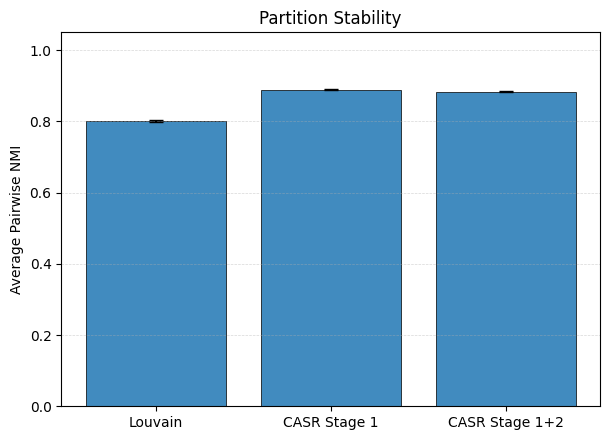

In [22]:
# =========================
# Stability experiment
# Louvain vs CASR Stage 1 vs CASR Stage 1+2
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

STABILITY_RUNS = 3
STABILITY_SEEDS = [42, 43, 44]

R = 5
TAU = 0.3
ALPHA = 0.2
MIN_SIZE = 100
STABILITY_THRESHOLD = 0.975
SEED = 42

STABILITY_DIR = "stability_results"
os.makedirs(STABILITY_DIR, exist_ok=True)

nodes_sorted = sorted(G.nodes())

def get_partition_labels(partition, nodes):
    return [partition[n] for n in nodes]

def average_pairwise_nmi(partitions, nodes):
    scores = []
    for i in range(len(partitions)):
        for j in range(i + 1, len(partitions)):
            labels_i = get_partition_labels(partitions[i], nodes)
            labels_j = get_partition_labels(partitions[j], nodes)
            scores.append(normalized_mutual_info_score(labels_i, labels_j))
    return float(np.mean(scores)), float(np.std(scores))

def unpack_stage1_output(stage1_output):
    # Compatible with both 3-return and 4-return versions
    if len(stage1_output) == 4:
        coarse_partition, consensus, stage1_runs, consensus_graph = stage1_output
    else:
        coarse_partition, consensus, stage1_runs = stage1_output
        consensus_graph = None
    return coarse_partition, consensus, stage1_runs, consensus_graph


print("Running stability experiment...")

louvain_partitions = []
stage1_partitions = []
casr_partitions = []

rows = []

for seed in STABILITY_SEEDS:
    print(f"Seed = {seed}")

    # 1. Louvain
    t0 = time.time()
    p_louvain = run_louvain(G, seed=seed)
    louvain_time = time.time() - t0
    louvain_partitions.append(p_louvain)

    # 2. CASR Stage 1
    t0 = time.time()
    stage1_output = stage1_consensus_partition(
        G,
        R=R,
        tau=TAU,
        seed=seed
    )
    coarse_partition, consensus, stage1_runs, consensus_graph = unpack_stage1_output(stage1_output)
    stage1_time = time.time() - t0
    stage1_partitions.append(coarse_partition)

    # 3. CASR Stage 1 + Stage 2
    t0 = time.time()
    final_partition, num_candidates, num_refined = stage2_refinement(
        G,
        coarse_partition,
        consensus,
        alpha=ALPHA,
        min_size=MIN_SIZE,
        stability_threshold=STABILITY_THRESHOLD,
        seed=seed
    )
    stage2_time = time.time() - t0
    casr_partitions.append(final_partition)

    rows.append({
        "seed": seed,
        "louvain_runtime": louvain_time,
        "stage1_runtime": stage1_time,
        "stage2_runtime": stage2_time,
        "refinement_candidates": num_candidates,
        "communities_refined": num_refined
    })

runtime_df = pd.DataFrame(rows)

louvain_stab_mean, louvain_stab_std = average_pairwise_nmi(louvain_partitions, nodes_sorted)
stage1_stab_mean, stage1_stab_std = average_pairwise_nmi(stage1_partitions, nodes_sorted)
casr_stab_mean, casr_stab_std = average_pairwise_nmi(casr_partitions, nodes_sorted)

stability_df = pd.DataFrame([
    {
        "method": "Louvain",
        "stability_pairwise_NMI_mean": louvain_stab_mean,
        "stability_pairwise_NMI_std": louvain_stab_std,
        "avg_runtime_seconds": runtime_df["louvain_runtime"].mean()
    },
    {
        "method": "CASR Stage 1",
        "stability_pairwise_NMI_mean": stage1_stab_mean,
        "stability_pairwise_NMI_std": stage1_stab_std,
        "avg_runtime_seconds": runtime_df["stage1_runtime"].mean()
    },
    {
        "method": "CASR Stage 1+2",
        "stability_pairwise_NMI_mean": casr_stab_mean,
        "stability_pairwise_NMI_std": casr_stab_std,
        "avg_runtime_seconds": (runtime_df["stage1_runtime"] + runtime_df["stage2_runtime"]).mean()
    }
])

stability_df.to_csv(f"{STABILITY_DIR}/stability_comparison.csv", index=False)
runtime_df.to_csv(f"{STABILITY_DIR}/stability_runtime_details.csv", index=False)

display(stability_df)

plt.figure(figsize=(6.2, 4.5))
plt.bar(
    stability_df["method"],
    stability_df["stability_pairwise_NMI_mean"],
    yerr=stability_df["stability_pairwise_NMI_std"],
    capsize=5,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6
)
plt.ylabel("Average Pairwise NMI")
plt.title("Partition Stability")
plt.ylim(0, 1.05)
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig(f"{STABILITY_DIR}/stability_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
##  Small-community over-merging comparison (Louvain vs CASR)

merge_ratio                                          \
                     count        mean         std  min        25%   
method                                                               
CASR Stage 1        1265.0  390.582043  585.889723  1.0  41.333333   
CASR Stage 1+2      1265.0  374.514208  576.617275  1.0  36.500000   
Louvain             1265.0  507.654687  701.197822  1.0  75.928571   

                                                    recovery_fraction  \
                       50%         75%          max             count   
method                                                                  
CASR Stage 1    155.500000  492.625000  3631.666667            1265.0   
CASR Stage 1+2  142.733333  467.833333  3631.666667            1265.0   
Louvain         241.833333  649.000000  4222.000000            1265.0   

                                                                  
                    mean       std       min  25%  50%  75%  max  
method                                                            
CASR Stage 1    0.998945  0.018927  0.404255  1.0  1.0  1.0  1.0  
CASR Stage 1+2  0.998945  0.018927  0.404255  1.0  1.0  1.0  1.0  
Louvain         0.998812  0.019659  0.404255  1.0  1.0  1.0  1.0

/tmp/ipykernel_4350/3045836692.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


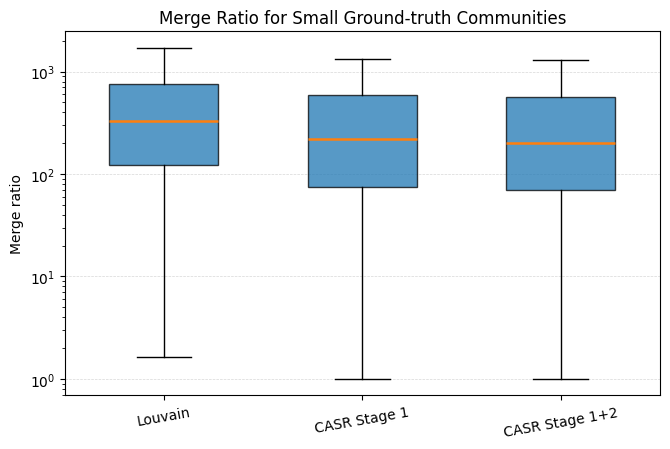

,method,gt_size_bin,merge_ratio
0,CASR Stage 1,small (<=20),221.611111
1,CASR Stage 1,medium (21-100),16.621212
2,CASR Stage 1,large (101-500),1.677632
3,CASR Stage 1+2,small (<=20),199.583333
4,CASR Stage 1+2,medium (21-100),14.478261
5,CASR Stage 1+2,large (101-500),1.677632
6,Louvain,small (<=20),328.309524
7,Louvain,medium (21-100),29.949603
8,Louvain,large (101-500),2.495495


In [23]:
# =========================
# Small-community over-merging comparison
# Louvain vs CASR
# =========================

MERGE_DIR = "merge_ratio_results"
os.makedirs(MERGE_DIR, exist_ok=True)

def compute_merge_ratio_df(partition, labels, method_name, min_gt_size=3):
    # detected community sizes
    detected_groups = {}
    for node, cid in partition.items():
        detected_groups.setdefault(cid, []).append(node)

    detected_size = {
        cid: len(nodes)
        for cid, nodes in detected_groups.items()
    }

    # ground-truth groups
    gt_groups = {}
    for node, lab in labels.items():
        if node in partition:
            gt_groups.setdefault(lab, []).append(node)

    rows = []

    for gt_lab, gt_nodes in gt_groups.items():
        gt_size = len(gt_nodes)

        if gt_size < min_gt_size:
            continue

        counts = {}
        for node in gt_nodes:
            detected_cid = partition[node]
            counts[detected_cid] = counts.get(detected_cid, 0) + 1

        dominant_detected = max(counts, key=counts.get)
        max_overlap = counts[dominant_detected]
        dominant_detected_size = detected_size[dominant_detected]

        recovery_fraction = max_overlap / gt_size
        merge_ratio = dominant_detected_size / gt_size

        rows.append({
            "method": method_name,
            "gt_label": gt_lab,
            "gt_size": gt_size,
            "dominant_detected_size": dominant_detected_size,
            "max_overlap": max_overlap,
            "recovery_fraction": recovery_fraction,
            "merge_ratio": merge_ratio
        })

    return pd.DataFrame(rows)


# Use the first stability run for comparison
merge_louvain = compute_merge_ratio_df(
    louvain_partitions[0],
    labels,
    "Louvain"
)

merge_stage1 = compute_merge_ratio_df(
    stage1_partitions[0],
    labels,
    "CASR Stage 1"
)

merge_casr = compute_merge_ratio_df(
    casr_partitions[0],
    labels,
    "CASR Stage 1+2"
)

merge_all_df = pd.concat(
    [merge_louvain, merge_stage1, merge_casr],
    ignore_index=True
)

merge_all_df["gt_size_bin"] = pd.cut(
    merge_all_df["gt_size"],
    bins=[0, 20, 100, 500, np.inf],
    labels=["small (<=20)", "medium (21-100)", "large (101-500)", "very large (>500)"]
)

merge_all_df.to_csv(f"{MERGE_DIR}/merge_ratio_comparison.csv", index=False)

display(
    merge_all_df.groupby("method")[
        ["merge_ratio", "recovery_fraction"]
    ].describe()
)

# Focus on small ground-truth communities
small_merge_df = merge_all_df[merge_all_df["gt_size"] <= 20].copy()

methods = ["Louvain", "CASR Stage 1", "CASR Stage 1+2"]
plot_data = [
    small_merge_df.loc[small_merge_df["method"] == m, "merge_ratio"].dropna().values
    for m in methods
]

plt.figure(figsize=(6.8, 4.6))
box = plt.boxplot(
    plot_data,
    labels=methods,
    showfliers=False,
    patch_artist=True,
    widths=0.55
)

for patch in box["boxes"]:
    patch.set_alpha(0.75)

for median in box["medians"]:
    median.set_linewidth(1.8)

plt.yscale("log")
plt.ylabel("Merge ratio")
plt.title("Merge Ratio for Small Ground-truth Communities")
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(f"{MERGE_DIR}/small_community_merge_ratio_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional: all size bins
summary_by_bin = (
    merge_all_df
    .groupby(["method", "gt_size_bin"])["merge_ratio"]
    .median()
    .reset_index()
)

display(summary_by_bin)

In [12]:
# =========================
# Motivation experiments: Louvain limitations
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import normalized_mutual_info_score

MOTIVATION_RUNS = 10
MOTIVATION_SEEDS = list(range(MOTIVATION_RUNS))

MOTIVATION_DIR = "motivation_results"
os.makedirs(MOTIVATION_DIR, exist_ok=True)

nodes_sorted = sorted(G.nodes())

def partition_to_labels(partition, nodes):
    return [partition[n] for n in nodes]

print(f"Running Louvain {MOTIVATION_RUNS} times for motivation experiments...")

louvain_partitions = []
louvain_rows = []

for seed in MOTIVATION_SEEDS:
    t0 = time.time()
    p = run_louvain(G, seed=seed)
    runtime = time.time() - t0

    ev = evaluate_partition(G, p, labels)
    ev["seed"] = seed
    ev["runtime_seconds"] = runtime

    louvain_partitions.append(p)
    louvain_rows.append(ev)

motivation_df = pd.DataFrame(louvain_rows)
motivation_df.to_csv(f"{MOTIVATION_DIR}/louvain_multiseed_results.csv", index=False)

motivation_df

Running Louvain 10 times for motivation experiments...


,num_communities,modularity,NMI,ARI,labeled_nodes,seed,runtime_seconds
0,239,0.926324,0.843145,0.330277,16716,0,46.509405
1,247,0.926023,0.841873,0.320505,16716,1,43.077833
2,238,0.925879,0.841280,0.318363,16716,2,49.862186
3,235,0.926122,0.841393,0.321719,16716,3,44.802769
4,239,0.926670,0.842108,0.326176,16716,4,47.071158
5,240,0.926055,0.843454,0.334608,16716,5,44.387287
6,237,0.926056,0.839326,0.310820,16716,6,43.453840
7,242,0.926044,0.842782,0.325585,16716,7,41.990571
8,246,0.926241,0.845221,0.340410,16716,8,45.582074
9,240,0.926322,0.838139,0.311627,16716,9,44.333148


Mean pairwise NMI across Louvain runs: 0.8023
Std pairwise NMI across Louvain runs: 0.0050


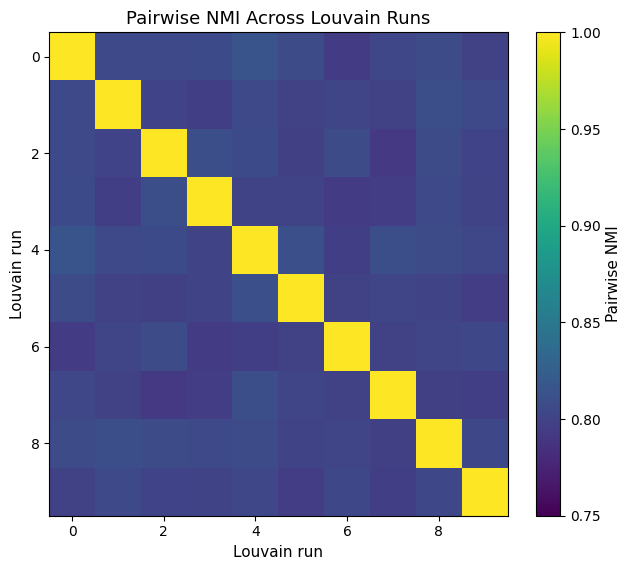

In [17]:
# =========================
# Experiment 1: Louvain instability
# Pairwise NMI heatmap between different Louvain runs
# =========================

n_runs = len(louvain_partitions)
pairwise_nmi = np.zeros((n_runs, n_runs))

partition_labels_list = [
    partition_to_labels(p, nodes_sorted)
    for p in louvain_partitions
]

for i in range(n_runs):
    for j in range(n_runs):
        pairwise_nmi[i, j] = normalized_mutual_info_score(
            partition_labels_list[i],
            partition_labels_list[j]
        )

pairwise_nmi_df = pd.DataFrame(pairwise_nmi)
pairwise_nmi_df.to_csv(f"{MOTIVATION_DIR}/louvain_pairwise_nmi.csv", index=False)

mean_pairwise_nmi = pairwise_nmi[np.triu_indices(n_runs, k=1)].mean()
std_pairwise_nmi = pairwise_nmi[np.triu_indices(n_runs, k=1)].std()

print(f"Mean pairwise NMI across Louvain runs: {mean_pairwise_nmi:.4f}")
print(f"Std pairwise NMI across Louvain runs: {std_pairwise_nmi:.4f}")

# plt.figure(figsize=(7, 6))
# plt.imshow(pairwise_nmi, aspect="auto")
# plt.colorbar(label="Pairwise NMI")
# plt.title("Louvain Instability: Pairwise NMI Across Random Seeds")
# plt.xlabel("Louvain run")
# plt.ylabel("Louvain run")
# plt.tight_layout()
# plt.savefig(f"{MOTIVATION_DIR}/fig1_louvain_pairwise_nmi_heatmap.png", dpi=300)
# plt.show()

plt.figure(figsize=(6.5, 5.8))

im = plt.imshow(
    pairwise_nmi,
    aspect="auto",
    cmap="viridis",
    vmin=0.75,
    vmax=1.00
)

cbar = plt.colorbar(im)
cbar.set_label("Pairwise NMI", fontsize=11)

plt.title("Pairwise NMI Across Louvain Runs", fontsize=13)
plt.xlabel("Louvain run", fontsize=11)
plt.ylabel("Louvain run", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig(f"{MOTIVATION_DIR}/fig1_louvain_pairwise_nmi_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

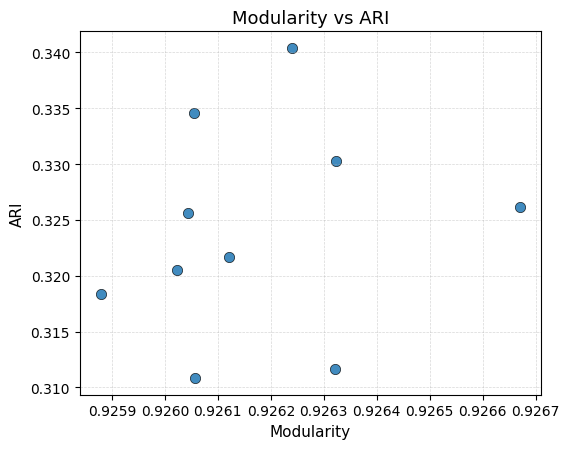

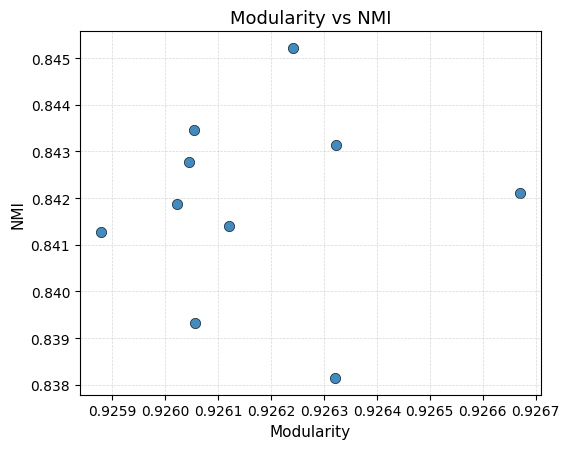

Louvain multi-seed metric summary:


,num_communities,modularity,NMI,ARI,runtime_seconds
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,240.300000,0.926174,0.841872,0.324009,45.107027
std,3.772709,0.000224,0.002034,0.009454,2.271420
min,235.000000,0.925879,0.838139,0.310820,41.990571
25%,238.250000,0.926047,0.841309,0.318898,43.673667
50%,239.500000,0.926089,0.841991,0.323652,44.595028
75%,241.500000,0.926301,0.843054,0.329252,46.277572
max,247.000000,0.926670,0.845221,0.340410,49.862186


In [18]:
# =========================
# Experiment 2: Modularity vs ground-truth accuracy
# =========================

plt.figure(figsize=(5.8, 4.6))
plt.scatter(
    motivation_df["modularity"],
    motivation_df["ARI"],
    s=55,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.5
)
plt.xlabel("Modularity", fontsize=11)
plt.ylabel("ARI", fontsize=11)
plt.title("Modularity vs ARI", fontsize=13)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{MOTIVATION_DIR}/fig2_modularity_vs_ari.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(5.8, 4.6))
plt.scatter(
    motivation_df["modularity"],
    motivation_df["NMI"],
    s=55,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.5
)
plt.xlabel("Modularity", fontsize=11)
plt.ylabel("NMI", fontsize=11)
plt.title("Modularity vs NMI", fontsize=13)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{MOTIVATION_DIR}/fig2_modularity_vs_nmi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Louvain multi-seed metric summary:")
display(
    motivation_df[
        ["num_communities", "modularity", "NMI", "ARI", "runtime_seconds"]
    ].describe()
)

/tmp/ipykernel_4350/3168976352.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


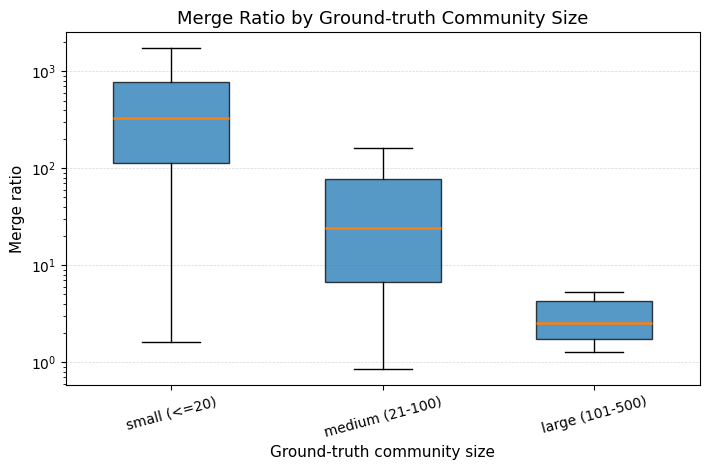

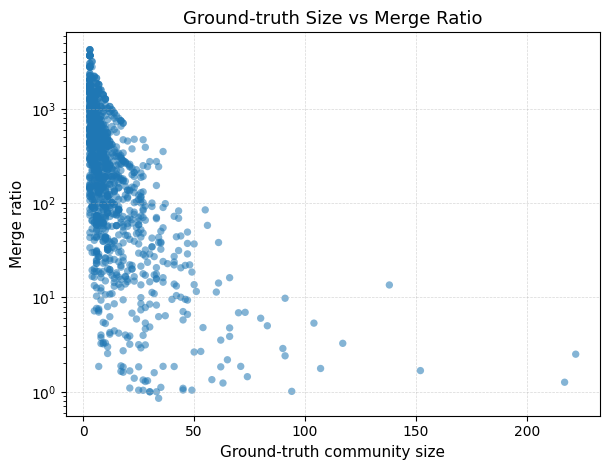

In [19]:
# Boxplot: merge ratio by ground-truth community size bin
plot_data = []
plot_labels = []

bin_order = ["small (<=20)", "medium (21-100)", "large (101-500)", "very large (>500)"]

for bin_name in bin_order:
    values = merge_df.loc[merge_df["gt_size_bin"] == bin_name, "merge_ratio"].dropna().values
    if len(values) > 0:
        plot_data.append(values)
        plot_labels.append(str(bin_name))

plt.figure(figsize=(7.2, 4.8))
box = plt.boxplot(
    plot_data,
    labels=plot_labels,
    showfliers=False,
    patch_artist=True,
    widths=0.55
)

for patch in box["boxes"]:
    patch.set_alpha(0.75)

for median in box["medians"]:
    median.set_linewidth(1.8)

plt.yscale("log")
plt.ylabel("Merge ratio", fontsize=11)
plt.xlabel("Ground-truth community size", fontsize=11)
plt.title("Merge Ratio by Ground-truth Community Size", fontsize=13)
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.xticks(rotation=15, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{MOTIVATION_DIR}/fig3_overmerging_by_gt_size.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional scatter plot
plt.figure(figsize=(6.2, 4.8))
plt.scatter(
    merge_df["gt_size"],
    merge_df["merge_ratio"],
    s=28,
    alpha=0.55,
    edgecolors="none"
)
plt.yscale("log")
plt.xlabel("Ground-truth community size", fontsize=11)
plt.ylabel("Merge ratio", fontsize=11)
plt.title("Ground-truth Size vs Merge Ratio", fontsize=13)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"{MOTIVATION_DIR}/fig3_gt_size_vs_merge_ratio.png", dpi=300, bbox_inches="tight")
plt.show()